In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
DEVICE

device(type='cpu')

In [ ]:
from matplotlib.pyplot import grid
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class SimplePolygonEnv(gym.Env):
    """Custom Environment that follows gymnasium interface"""
    
    def __init__(self, grid_dataset):
        super(SimplePolygonEnv, self).__init__()
        
        self.grid_dataset = grid_dataset # Pass your offline dataset here
        self.current_grid_idx = 0
        
        # Assume H=16, W=16 for this example. Change to your actual grid size.
        self.H, self.W = 16, 16 
        
        # ACTION SPACE: 4 Discrete Actions (0: Up, 1: Down, 2: Left, 3: Right)
        self.action_space = spaces.Discrete(4)
        self.action_mapping = {
            0: (-1, 0),  # Up
            1: (1, 0),   # Down
            2: (0, -1),  # Left
            3: (0, 1)    # Right
        }

        self.use_frontier_potential = False # Toggle for the global gravity reward
        
        # OBSERVATION SPACE: The exact 4-Channel tensor you feed your U-Net
        # Shape: (4, H, W), Values between 0.0 and 1.0
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(4, self.H, self.W), dtype=np.float32
        )
    
    def action_masks(self):
        """
        Returns a boolean array where True = Valid Action, False = Wall/Boundary.
        Order: [Up, Down, Left, Right] (matches your action_mapping)
        """
        mask = np.ones(4, dtype=bool)
        r, c = self.agent_pos
        
        for action_idx, (dr, dc) in self.action_mapping.items():
            nr, nc = r + dr, c + dc
            # If the neighbor is out of bounds OR is a wall, mask it out
            if not (0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0):
                mask[action_idx] = False
                
        return mask
    
    def _get_frontier_potential(self):
        """
        Calculates Manhattan distance to the nearest true frontier.
        Frontier: A known floor tile that orthogonally borders an unseen cell.
        """
        # 1. Identify Unseen cells
        unseen = (self.unseen_map == 1)
        
        # 2. Fast NumPy trick to find all cells that orthogonally border an unseen cell
        adj_unseen = np.zeros_like(unseen, dtype=bool)
        adj_unseen[:-1, :] |= unseen[1:, :]  # Check Up
        adj_unseen[1:, :] |= unseen[:-1, :]  # Check Down
        adj_unseen[:, :-1] |= unseen[:, 1:]  # Check Left
        adj_unseen[:, 1:] |= unseen[:, :-1]  # Check Right
        
        # 3. Apply your exact definition: Must be a floor (0), must be seen (0), and borders unseen
        is_known_floor = (self.grid == 0) & (self.unseen_map == 0)
        frontier_mask = is_known_floor & adj_unseen
        
        # Extract the coordinates of these specific frontier tiles
        frontier_coords = np.argwhere(frontier_mask)
        
        if len(frontier_coords) == 0:
            return 0 # Map is fully explored (or no frontiers exist)
            
        # 4. Calculate Manhattan distance from agent to all frontier tiles
        agent_r, agent_c = self.agent_pos
        distances = np.abs(frontier_coords[:, 0] - agent_r) + np.abs(frontier_coords[:, 1] - agent_c) + 1.0 # +1 to avoid division by zero and to give a small base potential even to adjacent frontiers
        
        total_potential = np.sum(1 / distances) # Closer frontiers contribute more to the potential
        return total_potential


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # 1. Load a random grid from your dataset
        self.grid = self.grid_dataset[np.random.randint(len(self.grid_dataset))]
        
        # 2. Spawn agent on a random clear floor tile
        free_cells = np.argwhere(self.grid == 0)
        spawn_idx = np.random.choice(len(free_cells))
        self.agent_pos = tuple(free_cells[spawn_idx])
        self.path = [self.agent_pos]
        self.cells_revealed_per_step = []
        
        # 3. Initialize Memory Maps
        self.known_obstacles = np.zeros_like(self.grid, dtype=np.float32)
        self.unseen_map = np.ones_like(self.grid, dtype=np.float32)
        # --- NEW BREADCRUMB MEMORY ---
        self.visit_count = np.zeros_like(self.grid, dtype=np.float32)
        
        self.step_count = 0
        self.max_steps = 256
        
        # 4. Generate initial observation
        obs = self._get_obs()
        
        if self.use_frontier_potential:
            self.previous_potential = self._get_frontier_potential() # For the global gravity reward
        # Gymnasium v0.26+ requires returning (observation, info_dict)
        return obs, {}

    def step(self, action):
        self.step_count += 1
        
        if isinstance(action, np.ndarray):
            action = action.item()
        # 1. Attempt to move the agent
        dr, dc = self.action_mapping[action]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc
        
        reward = -0.1 # Base time penalty (punishes dithering/hesitation)

         # 5. Check Termination Conditions
        terminated = False
        truncated = False
        
        # 2. Check collision
        if 0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0:
            # Valid move
            self.agent_pos = (nr, nc)
           
            self.path.append(self.agent_pos)
            
            # --- THE REVISIT PENALTY ---
            # If we have been here before, penalize it heavily. 
            # 1st visit = 0 penalty. 2nd visit = -0.1. 3rd visit = -0.2. etc.
            visits = self.visit_count[nr, nc]
            reward -= ((visits ** 2) * 0.1) #exponential penalty for repeated visits
            self.visit_count[nr, nc] += 1

            
            # ---------------------------
        else:
            reward -= 10 # Wall collision
            self.path.append(self.agent_pos) # Even if we hit a wall, we "visit" that cell for LOS purposes
            path_length_untill_now = len(self.path)
            self.path.extend((self.max_steps - path_length_untill_now) * [self.agent_pos]) # Pad the path to max length to avoid issues in the replay buffer
            self.step_count = self.max_steps # Force end of episode
            terminated = True

        # 3. Update Maps & Calculate New Information
        previous_unseen_count = self.unseen_map.sum()
        obs = self._get_obs() # This calls your LOS and Grazing functions
        current_unseen_count = self.unseen_map.sum()
        
        
        # 4. Reward Shaping: Reward the agent for discovering new floor
        cells_revealed = previous_unseen_count - current_unseen_count
        if cells_revealed >= 0:
            reward += cells_revealed * 5.0
            self.cells_revealed_per_step.append(cells_revealed)

        if self.use_frontier_potential:
            # --- THE GLOBAL GRAVITY REWARD ---
            current_potential = self._get_frontier_potential()
            # Did the global pull get stronger (we moved closer) or weaker (we moved away)?
            potential_change = current_potential - self.previous_potential
            # potential_change is POSITIVE if we got closer to the fog mass (Good)
            # potential_change is NEGATIVE if we moved further away (Bad)
            reward += (potential_change * 10) # You may need to tune this multiplier!
            
            self.previous_potential = current_potential
            # ---------------------------------
            
        # 2. The Exact Termination Condition
        unseen_floor_count = np.sum(self.unseen_map[self.grid == 0])
        
        # Did we explore everything?
        if unseen_floor_count == 0:  
            terminated = True
            # --- THE SPEED BONUS ---
            # Max possible steps is self.max_steps. We reward the agent for unused time.
            steps_remaining = self.max_steps - self.step_count
            
            # Base completion (+10) plus a scaling bonus for speed (e.g., +0.1 per saved step)
            speed_bonus = steps_remaining * 0.1
            reward += (50.0 + speed_bonus)
            
        # Did we run out of time? (e.g., trapped in a loop)
        if self.step_count >= self.max_steps:
            truncated = True

        return obs, float(reward), terminated, truncated, {"path": self.path, "cells_revealed": self.cells_revealed_per_step, "reward": reward}

    def _get_obs(self):
        """Builds the 3-channel state tensor identically to your U-Net"""
        agent_layer = np.zeros_like(self.grid, dtype=np.float32)
        agent_layer[self.agent_pos] = 1.0
        
        # NOTE: Call your exact LOS functions here
        expanded_los_ = get_LOS4_visibility_map(self.grid, self.path)
        expanded_los = apply_grazing_los(self.grid, expanded_los_)
        
        # For boilerplate, assuming expanded_los is calculated:
        self.unseen_map[expanded_los == 1] = 0.0
        visible_walls = expanded_los & (self.grid == 1)
        self.known_obstacles[visible_walls] = 1.0
        # Normalize the visit count so the neural network can read it safely [0.0 to 1.0]
        # (Assuming it rarely visits a single cell more than 10 times if exploring optimally)
        visit_heatmap = np.clip(self.visit_count / 10.0, 0.0, 1.0)
        
        state_tensor = np.stack([
            self.known_obstacles, 
            agent_layer, 
            self.unseen_map, 
            visit_heatmap # <-- The new 4th channel
        ], axis=0)
        
        return state_tensor

In [4]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from autoregressive_unet import ResidualConv

class CustomGridCNN(BaseFeaturesExtractor):
    """
    A custom CNN tailored for tiny 16x16 grids.
    """

    def _get_coord_channels(self, batch_size, height, width, device):
        """Generates normalized coordinate channels"""
        y_coords = torch.linspace(-1, 1, steps=height, device=device).view(1, 1, height, 1).expand(batch_size, 1, height, width)
        x_coords = torch.linspace(-1, 1, steps=width, device=device).view(1, 1, 1, width).expand(batch_size, 1, height, width)
        return x_coords, y_coords
    
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 512):
        super(CustomGridCNN, self).__init__(observation_space, features_dim)
        
        n_input_channels = observation_space.shape[0] + 2  # Original channels + 2 for coordinates
        
        self.cnn = nn.Sequential(
            # 16x16 -> 16x16
            nn.Conv2d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 16x16 -> 8x8
            nn.MaxPool2d(2),
            # 8x8 -> 8x8
            nn.Conv2d(32, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 8x8 -> 4x4
            nn.MaxPool2d(2),
            nn.Flatten(),
        )

        # Compute shape by doing one forward pass with dummy data
        with torch.no_grad():
            dummy_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            batch_size, _, height, width = dummy_tensor.shape
            device = dummy_tensor.device
            x_coords, y_coords = self._get_coord_channels(batch_size, height, width, device)
            dummy_tensor = torch.cat([dummy_tensor, x_coords, y_coords], dim=1)
            n_flatten = self.cnn(dummy_tensor).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim), 
            nn.ReLU()
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        batch_size, _, height, width = observations.shape
        device = observations.device
        x_coords, y_coords = self._get_coord_channels(batch_size, height, width, device)
        observations_ = torch.cat([observations, x_coords, y_coords], dim=1)
        return self.linear(self.cnn(observations_))

Generated Grid:


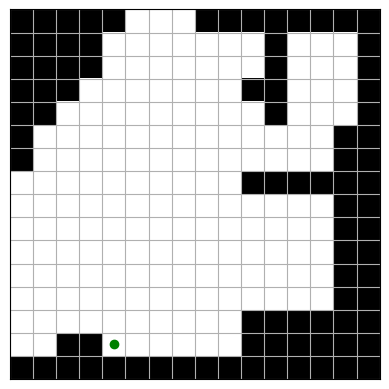

In [5]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
# grid, start = gen.generate_valid_grid(density=5)
grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


In [ ]:
N = 20_000
grid_dataset = []
for _i in range(N):
    grid, start = gen.generate_simple_polygon_grid()
    grid_dataset.append(grid)
np.array(grid_dataset).shape

In [7]:
# import stable_baselines3
# stable_baselines3.common.env_checker.check_env(SimplePolygonEnv(grid_dataset=grid_dataset), warn=True)

In [8]:
# from stable_baselines3 import PPO

# # Tell SB3 to use your CustomGridCNN instead of NatureCNN
# policy_kwargs = dict(
#     features_extractor_class=CustomGridCNN,
#     features_extractor_kwargs=dict(features_dim=512),
# )

# env = SimplePolygonEnv(grid_dataset=grid_dataset)

# print("Starting PPO Training with Custom CNN...")
# model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1, learning_rate=0.0003)

# model.learn(total_timesteps=5_000_000, progress_bar=True, log_interval=100)

In [9]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.maskable.evaluation import evaluate_policy
from sb3_contrib.common.wrappers import ActionMasker
# 1. Initialize the environment
env = SimplePolygonEnv(grid_dataset=grid_dataset)
env = ActionMasker(env, action_mask_fn=lambda env: env.action_masks())
policy_kwargs = dict(
    features_extractor_class=CustomGridCNN,
    features_extractor_kwargs=dict(features_dim=512),
)
# 2. Setup the Maskable PPO model
# Note: Use 'MultiInputPolicy' if you have complex obs, 
# or 'CnnPolicy' for your current grid setup.
model = MaskablePPO(
    "CnnPolicy", 
    env, 
    policy_kwargs=policy_kwargs, 
    verbose=1, 
    learning_rate=0.0003, 
)
# 3. Train
model.learn(total_timesteps=10_000_000, log_interval=100, progress_bar=True)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Output()

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 231         |
|    ep_rew_mean          | 590         |
| time/                   |             |
|    fps                  | 277         |
|    iterations           | 100         |
|    time_elapsed         | 738         |
|    total_timesteps      | 204800      |
| train/                  |             |
|    approx_kl            | 0.015255643 |
|    clip_fraction        | 0.195       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.08       |
|    explained_variance   | 0.87        |
|    learning_rate        | 0.0003      |
|    loss                 | 46.9        |
|    n_updates            | 990         |
|    policy_gradient_loss | -0.00458    |
|    value_loss           | 1.71e+03    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 235         |
|    ep_rew_mean          | 259         |
| time/                   |             |
|    fps                  | 267         |
|    iterations           | 200         |
|    time_elapsed         | 1532        |
|    total_timesteps      | 409600      |
| train/                  |             |
|    approx_kl            | 0.013670088 |
|    clip_fraction        | 0.188       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.13       |
|    explained_variance   | 0.208       |
|    learning_rate        | 0.0003      |
|    loss                 | 2.38e+04    |
|    n_updates            | 1990        |
|    policy_gradient_loss | 0.00492     |
|    value_loss           | 3.93e+04    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 236         |
|    ep_rew_mean          | -1.44e+03   |
| time/                   |             |
|    fps                  | 257         |
|    iterations           | 300         |
|    time_elapsed         | 2389        |
|    total_timesteps      | 614400      |
| train/                  |             |
|    approx_kl            | 0.012012206 |
|    clip_fraction        | 0.147       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.15       |
|    explained_variance   | 0.946       |
|    learning_rate        | 0.0003      |
|    loss                 | 24.7        |
|    n_updates            | 2990        |
|    policy_gradient_loss | -0.00259    |
|    value_loss           | 162         |
-----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 221         |
|    ep_rew_mean          | 482         |
| time/                   |             |
|    fps                  | 220         |
|    iterations           | 4400        |
|    time_elapsed         | 40937       |
|    total_timesteps      | 9011200     |
| train/                  |             |
|    approx_kl            | 0.016139837 |
|    clip_fraction        | 0.176       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.15       |
|    explained_variance   | 0.96        |
|    learning_rate        | 0.0003      |
|    loss                 | 15.4        |
|    n_updates            | 43990       |
|    policy_gradient_loss | 0.00251     |
|    value_loss           | 129         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 232         |
|    ep_rew_mean          | 118         |
| time/                   |             |
|    fps                  | 220         |
|    iterations           | 4500        |
|    time_elapsed         | 41787       |
|    total_timesteps      | 9216000     |
| train/                  |             |
|    approx_kl            | 0.012311737 |
|    clip_fraction        | 0.16        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.14       |
|    explained_variance   | 0.785       |
|    learning_rate        | 0.0003      |
|    loss                 | 220         |
|    n_updates            | 44990       |
|    policy_gradient_loss | -0.00369    |
|    value_loss           | 1.54e+03    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 230         |
|    ep_rew_mean          | -502        |
| time/                   |             |
|    fps                  | 221         |
|    iterations           | 4600        |
|    time_elapsed         | 42627       |
|    total_timesteps      | 9420800     |
| train/                  |             |
|    approx_kl            | 0.010896783 |
|    clip_fraction        | 0.138       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.13       |
|    explained_variance   | 0.679       |
|    learning_rate        | 0.0003      |
|    loss                 | 373         |
|    n_updates            | 45990       |
|    policy_gradient_loss | -0.00297    |
|    value_loss           | 1.47e+03    |
-----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 236        |
|    ep_rew_mean          | 51.1       |
| time/                   |            |
|    fps                  | 221        |
|    iterations           | 4700       |
|    time_elapsed         | 43474      |
|    total_timesteps      | 9625600    |
| train/                  |            |
|    approx_kl            | 0.03598879 |
|    clip_fraction        | 0.305      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.01      |
|    explained_variance   | -0.177     |
|    learning_rate        | 0.0003     |
|    loss                 | 9.35e+03   |
|    n_updates            | 46990      |
|    policy_gradient_loss | 0.00252    |
|    value_loss           | 1.03e+05   |
----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 242         |
|    ep_rew_mean          | -474        |
| time/                   |             |
|    fps                  | 221         |
|    iterations           | 4800        |
|    time_elapsed         | 44323       |
|    total_timesteps      | 9830400     |
| train/                  |             |
|    approx_kl            | 0.023018807 |
|    clip_fraction        | 0.281       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.01       |
|    explained_variance   | 0.863       |
|    learning_rate        | 0.0003      |
|    loss                 | 29.9        |
|    n_updates            | 47990       |
|    policy_gradient_loss | -0.00082    |
|    value_loss           | 297         |
-----------------------------------------


In [20]:
import numpy as np
from stable_baselines3 import PPO

# # 1. Load the RAW test dataset (Ground truth grids, not X_test/y_test tensors)
# # Assuming you have 750 raw test grids based on your previous data
# raw_test_grids = np.load("data/raw_simple_polygons_test.npy") 

# 2. Initialize the environment with the TEST data
eval_env = SimplePolygonEnv(grid_dataset=grid_dataset)

# 3. Load the trained model
# Replace with your actual saved model path
# model = PPO.load("ppo_baseline_agent")

ppo_path_lengths = []
success_count = 0

print(f"Evaluating PPO Baseline on {len(grid_dataset)} test environments...")

for i in range(len(grid_dataset)):
    # Force the environment to use the specific test grid sequentially
    eval_env.grid_dataset = [grid_dataset[i]] 
    obs, info = eval_env.reset()
    
    done = False
    steps_taken = 0
    
    while not done:
        # deterministic=True forces the agent to take the action with the highest probability
        action_mask = get_action_masks(eval_env)
        action, _states = model.predict(obs, deterministic=True, action_masks=action_mask)
        
        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        steps_taken += 1
        
        if terminated or truncated:
            done = True
            ppo_path_lengths.append(steps_taken)
            if terminated:
                success_count += 1
            
    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(grid_dataset)} grids...")

# --- THE FINAL METRICS ---
print("\n--- PPO Baseline Results ---")
print(f"Total Successes (Explored 100%): {success_count} / {len(grid_dataset)}")
print(f"Success Rate: {(success_count / len(grid_dataset)) * 100:.2f}%")
print(f"Average Path Length (including timeouts): {np.mean(ppo_path_lengths):.2f}")

Evaluating PPO Baseline on 10000 test environments...
Evaluated 50/10000 grids...
Evaluated 100/10000 grids...


KeyboardInterrupt: 

Agent failed to explore the entire grid within the step limit.


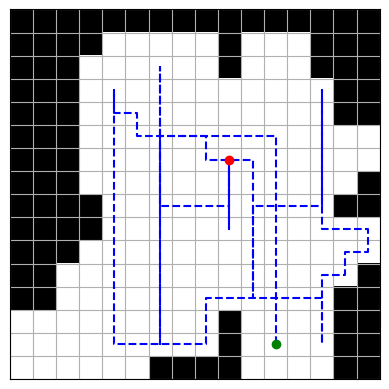

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO
eval_env = SimplePolygonEnv(grid_dataset=grid_dataset)
rnd = np.random.randint(len(grid_dataset))

# Load a single grid for visualization
eval_env.grid_dataset = [grid_dataset[rnd]] 
obs, info = eval_env.reset()
grid = eval_env.grid

done = False
while not done:
    action_mask = get_action_masks(eval_env)
    # print("Action Mask:", action_mask)
    action, _states = model.predict(obs, deterministic=True, action_masks=action_mask)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    if terminated or truncated:
        done = True
        if terminated:
            print("Agent successfully explored the entire grid!")
        else:
            print("Agent failed to explore the entire grid within the step limit.")

# Extract the path it took
path = info['path']

plot_path(grid, path)

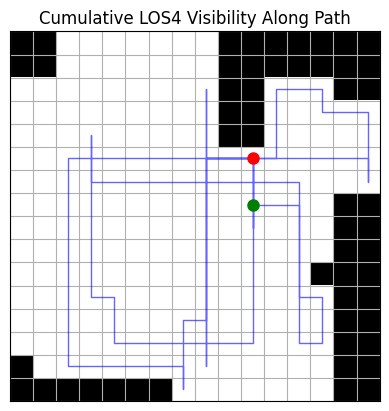

In [22]:
plot_visibility(grid, path)

In [18]:
path

[(1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (3, 14),
 (4, 14),
 (5, 14),
 (6, 14),
 (7, 14),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (6, 15),
 (7, 15),
 (7, 14),
 (7, 15),
 (7, 14),
 (7, 15),
 (7, 14),
 (7, 15),
 (7, 14),
 (7, 13),
 (7, 12),
 (8, 12),
 (9, 12),
 (9, 11),
 (10, 11),
 (11, 11),
 (10, 11),
 (10, 10),
 (10, 9),
 (10, 8),
 (10, 7),
 (11, 7),
 (12, 7),
 (11, 7),
 (10, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (7, 7),
 (6, 7),
 (5, 7),
 (4, 7),
 (3, 7),
 (2, 7),
 (3, 7),
 (2, 7),
 (3, 7),
 (2, 7),
 (3, 7),
 (2, 7),
 (3, 7),
 (2, 7),
 (3, 7),
 (4, 7),
 (5, 7),
 (6, 7),
 (7, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 (9, 7),
 (8, 7),
 

In [79]:
len(path)

256

In [30]:
info["reward"]

np.float64(-10.1)

In [31]:
info["cells_revealed"]

[np.float32(15.0),
 np.float32(20.0),
 np.float32(12.0),
 np.float32(12.0),
 np.float32(4.0)]

In [85]:
len(info["cells_revealed"])
path[:23]

[(np.int64(13), np.int64(1)),
 (np.int64(13), np.int64(2)),
 (np.int64(13), np.int64(3)),
 (np.int64(13), np.int64(4)),
 (np.int64(13), np.int64(5)),
 (np.int64(13), np.int64(6)),
 (np.int64(13), np.int64(7)),
 (np.int64(13), np.int64(8)),
 (np.int64(13), np.int64(9)),
 (np.int64(13), np.int64(10)),
 (np.int64(13), np.int64(11)),
 (np.int64(13), np.int64(12)),
 (np.int64(12), np.int64(12)),
 (np.int64(11), np.int64(12)),
 (np.int64(10), np.int64(12)),
 (np.int64(9), np.int64(12)),
 (np.int64(8), np.int64(12)),
 (np.int64(7), np.int64(12)),
 (np.int64(6), np.int64(12)),
 (np.int64(5), np.int64(12)),
 (np.int64(4), np.int64(12)),
 (np.int64(3), np.int64(12)),
 (np.int64(3), np.int64(12))]